In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import pandas as pd
import re
from collections import Counter
import numpy as np
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier



In [2]:
df = pd.read_csv("../data/2023_2024_CLEAN.csv")
df

,stu_id,variable,Who am I?,code,valence
0,stu_NZWIU92234,TST Respose 8,I am going to 7grade,22.0,6thgrade
1,stu_NZWIU92234,TST Respose 8,I am going to 7grade,4.0,6thgrade
2,stu_NZWIU92234,TST Respose 8,I am going to 7grade,14.0,neutral
3,stu_DJCZE13885,TST Respose 12,I like going outside.,31.0,positive
4,stu_DJCZE13885,TST Respose 12,I like going outside.,24.0,positive
...,...,...,...,...,...
6224,stu_CLLRZ76280,TST Respose 4,I like video games,24.0,positive
6225,stu_VENGZ10475,TST Respose 6,An honors student,43.0,positive
6226,stu_VENGZ10475,TST Respose 6,An honors student,14.0,positive
6227,stu_FQKSK24193,TST Respose 15,i have 3 little sisters,12.0,neutral


In [3]:
df.rename(columns={'Who am I?': 'who_am_i'}, inplace=True)
df = df.dropna(subset=['who_am_i', 'code'])
y = df['code']


tfidf = TfidfVectorizer(stop_words='english', max_features=300)
X = tfidf.fit_transform(df['who_am_i'])

print("X shape:", X.shape)


X shape: (6228, 300)


Term Frequency – Inverse Document Frequency

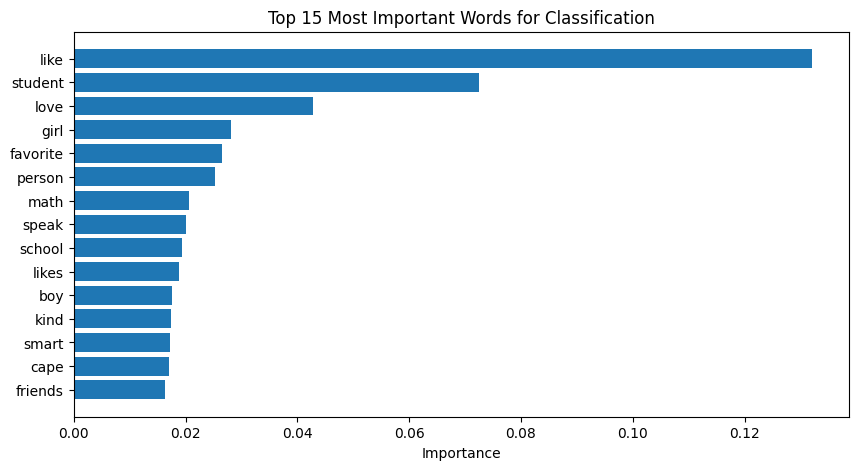

In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=1000, min_samples_leaf=5, random_state=42)
model.fit(X, y)

feature_names = tfidf.get_feature_names_out()
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(feat_df['feature'][:15][::-1], feat_df['importance'][:15][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Most Important Words for Classification")
plt.show()

In [5]:

import matplotlib.pyplot as plt


In [6]:
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, cohen_kappa_score

pipe = Pipeline([
    ('fs', SelectFromModel(RandomForestClassifier(min_samples_leaf=5), threshold='median')),
    ('model', KNeighborsClassifier(5))
])

scorer = make_scorer(cohen_kappa_score)
xval = KFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(pipe, X, y, cv=xval, scoring=scorer, return_train_score=True)

print('Kappa mean:', results['test_score'].mean())
print('Kappa SD:', results['test_score'].std())
print('Train kappa mean:', results['train_score'].mean())


Kappa mean: 0.37015631932248233
Kappa SD: 0.013226113250312812
Train kappa mean: 0.4760792498075981


To explore which features (words) best differentiate student identity statements, I applied feature selection using a Random Forest classifier on TF-IDF-transformed text responses from the "Who Am I?" dataset. First, I converted the text into numerical features using TF-IDF vectorization, which resulted in 8,230 rows and 300 word features. I then trained a Random Forest model to compute feature importances, identifying which words most contributed to predicting the identity category (code). Words like "like", "student", and "love" were ranked as the most important. To evaluate model performance, I created a pipeline that included feature selection (keeping the top 50% most important features) and a K-Nearest Neighbors (KNN) classifier. Using 5-fold cross-validation, I achieved a mean kappa score of 0.37, indicating moderate agreement between predictions and true categories. This pipeline helps reduce dimensionality and shows how certain words are more  associated with specific identity categories.

Ignore qualitative text, do some feature with categories and valences, .describe? column for each categories, count for each person. One-hot encoding for each person. what is the most common response per person. valence counting (positve, negative, neutral). one-hot encode most common words. mapping the tf-idf to gorodon, how many responses do they have inthe common categories (are the responses "like" other students responses, coutn responses per student).


In [7]:
# One-hot encode the 'who_am_i' column for the most common words
common_words_encoded = pd.get_dummies(df['who_am_i'], prefix='common_word')

# Group with the original dataframe
df_with_common_words = pd.concat([df, common_words_encoded], axis=1)

# most common response per person
most_common_response = df.groupby('stu_id')['who_am_i'].agg(lambda x: x.value_counts().idxmax())

# print
print("Most common response per person:")
print(most_common_response.head())


Most common response per person:
stu_id
stu_ABSGH36082                               I like sports
stu_AHWRN95528    I am someone who likes going to the pool
stu_ANAWT41929                                 I love xbox
stu_ANQAT24428                somebody who is a big sister
stu_AQNHF52456        i work in comstrution with my father
Name: who_am_i, dtype: object


In [8]:
# One-hot encode the 'valence' column
valence_encoded = pd.get_dummies(df['valence'], prefix='valence')

# Concatenate the one-hot encoded valence features with the original dataframe
df_with_valence_features = pd.concat([df, valence_encoded], axis=1)

# Display the first few rows of the updated dataframe
df_with_valence_features

,stu_id,variable,who_am_i,code,valence,valence_11,valence_12,valence_13,valence_14,valence_21,...,valence_vietnameseunderstanding,valence_volunteer,valence_west african,valence_white,valence_white and african american,valence_woman,valence_young,valence_youngest,valence_youngestchild,valence_youngwoman
0,stu_NZWIU92234,TST Respose 8,I am going to 7grade,22.0,6thgrade,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,stu_NZWIU92234,TST Respose 8,I am going to 7grade,4.0,6thgrade,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,stu_NZWIU92234,TST Respose 8,I am going to 7grade,14.0,neutral,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,stu_DJCZE13885,TST Respose 12,I like going outside.,31.0,positive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,stu_DJCZE13885,TST Respose 12,I like going outside.,24.0,positive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6224,stu_CLLRZ76280,TST Respose 4,I like video games,24.0,positive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6225,stu_VENGZ10475,TST Respose 6,An honors student,43.0,positive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6226,stu_VENGZ10475,TST Respose 6,An honors student,14.0,positive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6227,stu_FQKSK24193,TST Respose 15,i have 3 little sisters,12.0,neutral,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Count how many responses each student has
response_counts = df.groupby('stu_id').size().rename('response_count')

# Merge with main dataframe if not already per-user
df_user = df.drop_duplicates('stu_id').set_index('stu_id')
df_user = df_user.join(response_counts)

valence_counts = df.groupby(['stu_id', 'valence']).size().unstack(fill_value=0)

df_user = df_user.join(valence_counts)
df_user


,variable,who_am_i,code,valence,response_count,11,12,13,14,21,...,vietnameseunderstanding,volunteer,west african,white,white and african american,woman,young,youngest,youngestchild,youngwoman
stu_id,,,,,,,,,,,,,,,,,,,,,
stu_NZWIU92234,TST Respose 8,I am going to 7grade,22.0,6thgrade,28,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_DJCZE13885,TST Respose 12,I like going outside.,31.0,positive,29,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_CDXSC86692,TST Respose 17,i am the person that goes to my brothers dad's...,12.0,neutral,36,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_KWMWG76590,TST Respose 16,i have a lot of friends,10.0,positive,33,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_RFRYE74718,TST Respose 8,I am a fellow citizen for united states.,8.0,american,31,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
stu_PSHPN85751,TST Respose 2,i like science,25.0,positive,24,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_KGOWI06896,TST Respose 12,I like to play sports,29.0,positive,37,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stu_VFKRH03938,TST Respose 14,i am a funny person,46.0,positive,31,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Filter to only valid valence values
valid_valences = ['positive', 'neutral', 'negative']
df_clean = df[df['valence'].isin(valid_valences)].copy()

# Drop rows with missing code or stu_id (essential for grouping)
df_clean = df_clean.dropna(subset=['code', 'stu_id'])

# Convert code to integer if it's not already
df_clean['code'] = df_clean['code'].astype(int)

# One-hot encode 'valence' and 'code' columns
encoded = pd.get_dummies(df_clean[['stu_id', 'code', 'valence']], columns=['code', 'valence'])

# Group by student ID and sum the one-hot counts to get features per student
student_feature_matrix = encoded.groupby('stu_id').sum().reset_index()

# Add: total response count per student
student_feature_matrix['response_count'] = df_clean.groupby('stu_id').size()
student_feature_matrix

,stu_id,code_2,code_5,code_9,code_10,code_11,code_12,code_13,code_14,code_21,...,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive,response_count
0,stu_ABSGH36082,0,0,0,0,0,0,1,0,0,...,2,1,0,1,1,0,0,5,13,NaN
1,stu_AHWRN95528,0,0,0,1,0,1,0,1,0,...,1,1,0,0,0,0,0,2,30,NaN
2,stu_ANAWT41929,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,1,33,NaN
3,stu_ANQAT24428,0,0,0,1,0,3,0,1,0,...,1,1,2,0,0,0,0,6,16,NaN
4,stu_AQNHF52456,0,0,0,0,0,2,4,1,0,...,4,2,0,1,0,0,0,9,9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,stu_YXJEP22115,0,0,0,0,0,1,0,3,0,...,3,1,1,0,0,0,0,10,10,NaN
215,stu_ZARRQ26344,0,0,0,1,0,6,0,1,0,...,0,0,0,0,0,0,1,7,13,NaN
216,stu_ZQMQQ26810,0,0,0,1,0,1,0,2,0,...,1,1,0,1,0,0,3,2,21,NaN
217,stu_ZUARE93356,0,0,0,1,0,2,0,2,0,...,1,0,0,0,0,0,0,4,18,NaN


In [11]:

# Identify all valence and code columns
valence_cols = [col for col in student_feature_matrix.columns if col.startswith("valence_")]
code_cols = [col for col in student_feature_matrix.columns if col.startswith("code_")]

# For each student, keep only the most frequent code (set to 1), zero out others
student_feature_matrix[code_cols] = (student_feature_matrix[code_cols].eq(student_feature_matrix[code_cols].max(axis=1), axis=0)).astype(int)

# Do the same for valence columns
student_feature_matrix[valence_cols] = (student_feature_matrix[valence_cols].eq(student_feature_matrix[valence_cols].max(axis=1), axis=0)).astype(int)
student_feature_matrix

# Keep only stu_id + code_ + valence_ columns
final_cols = ['stu_id'] + code_cols + valence_cols
student_binary_features = student_feature_matrix[final_cols]
# First, rename the column in student_binary_features to prevent conflict
student_binary_features = student_binary_features.rename(columns={"stu_id": "original_stu_id"})
student_binary_features


,original_stu_id,code_2,code_5,code_9,code_10,code_11,code_12,code_13,code_14,code_21,...,code_42,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive
0,stu_ABSGH36082,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,stu_AHWRN95528,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,stu_ANAWT41929,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,stu_ANQAT24428,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,stu_AQNHF52456,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,stu_YXJEP22115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
215,stu_ZARRQ26344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
216,stu_ZQMQQ26810,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
217,stu_ZUARE93356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [12]:
main_df = pd.read_csv("../data/23_24_features_for_test_score_prediction.csv")
main_df

,test_scaled_score,user_id,probability_predict_count,probability_predict_mean,probability_predict_std,probability_predict_min,probability_predict_25%,probability_predict_50%,probability_predict_75%,probability_predict_max,label_predict_count,label_predict_mean,label_predict_std,label_predict_min,label_predict_25%,label_predict_50%,label_predict_75%,label_predict_max
0,506,stu_AADMK73299,1594,0.147714,0.262133,0.000133,0.001262,0.014827,0.117193,0.952113,1594,0.144291,0.351495,0,0.0,0.0,0.0,1
1,443,stu_AAIDO19370,781,0.367688,0.367039,0.000133,0.013299,0.225953,0.761520,0.955126,781,0.377721,0.485128,0,0.0,0.0,1.0,1
2,494,stu_ADLUE68736,1804,0.146234,0.262101,0.000118,0.001040,0.009183,0.116745,0.954448,1804,0.141907,0.349051,0,0.0,0.0,0.0,1
3,460,stu_ADXQN52075,1198,0.238787,0.310339,0.000118,0.003584,0.059522,0.465088,0.955126,1198,0.234558,0.423899,0,0.0,0.0,0.0,1
4,522,stu_AECSP94818,1819,0.122743,0.248185,0.000133,0.000550,0.004733,0.062297,0.955059,1819,0.117647,0.322278,0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3636,487,stu_ZVDDL53861,437,0.236658,0.336938,0.000133,0.001648,0.013718,0.507119,0.955126,437,0.251716,0.434496,0,0.0,0.0,1.0,1
3637,496,stu_ZWTAM54584,474,0.281424,0.356667,0.000133,0.002562,0.048265,0.594984,0.954448,474,0.284810,0.451801,0,0.0,0.0,1.0,1
3638,492,stu_ZWYRB65502,441,0.097094,0.197672,0.000133,0.000543,0.003921,0.064461,0.905482,441,0.083900,0.277553,0,0.0,0.0,0.0,1
3639,476,stu_ZXOBL50985,782,0.219003,0.297637,0.000133,0.003777,0.047141,0.369205,0.954448,782,0.203325,0.402730,0,0.0,0.0,0.0,1


In [13]:
# Find the intersection of student IDs between main_df and student_binary_features
common_students = set(main_df['user_id']).intersection(set(df['stu_id']))

# Print the count of common students
print(f"Number of students in main_df also present in df: {len(common_students)}")

Number of students in main_df also present in df: 0


In [14]:

mapping_df = pd.read_csv("../data/2024-09-19_TST_Anon_Mapping_Update_onlyTST_students.csv")
# Now merge safely using mapping
mapped = student_binary_features.merge(
    mapping_df,
    on="original_stu_id",
    how="left"
)

mapped

,original_stu_id,code_2,code_5,code_9,code_10,code_11,code_12,code_13,code_14,code_21,...,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive,new_stu_id
0,stu_ABSGH36082,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_UKGPX92064
1,stu_AHWRN95528,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_IJSGF14673
2,stu_ANAWT41929,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_VVKPX54196
3,stu_ANQAT24428,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_BYGHT94102
4,stu_AQNHF52456,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,1,stu_ZNRJF67227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,stu_YXJEP22115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,stu_MREDF50987
215,stu_ZARRQ26344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_RGCUK14418
216,stu_ZQMQQ26810,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_BUTRL72171
217,stu_ZUARE93356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_LCJWY74265


In [15]:
# Then, rename new_stu_id to match main_df
mapped = mapped.rename(columns={"new_stu_id": "stu_id"})

# Drop original_stu_id (optional)
mapped = mapped.drop(columns=["original_stu_id"])


mapped

,code_2,code_5,code_9,code_10,code_11,code_12,code_13,code_14,code_21,code_23,...,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive,stu_id
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_UKGPX92064
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_IJSGF14673
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_VVKPX54196
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_BYGHT94102
4,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,1,1,stu_ZNRJF67227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,stu_MREDF50987
215,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_RGCUK14418
216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_BUTRL72171
217,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,stu_LCJWY74265


In [16]:
main_df['stu_id'] = main_df['user_id']

merged_df = main_df.merge(mapped, on="stu_id", how="outer")
merged_df = merged_df.dropna().reset_index(drop=True)
merged_df.drop(columns=["stu_id"], inplace=True)
merged_df

,test_scaled_score,user_id,probability_predict_count,probability_predict_mean,probability_predict_std,probability_predict_min,probability_predict_25%,probability_predict_50%,probability_predict_75%,probability_predict_max,...,code_42,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive
0,494.0,stu_ADLUE68736,1804.0,0.146234,0.262101,0.000118,0.001040,0.009183,0.116745,0.954448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,488.0,stu_AKVDT62334,1662.0,0.158631,0.271783,0.000118,0.001186,0.012598,0.162616,0.953383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,524.0,stu_AUUJV42407,1971.0,0.062262,0.168691,0.000133,0.000552,0.002290,0.015722,0.919831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,526.0,stu_AWGOR50648,1482.0,0.095114,0.209007,0.000133,0.000809,0.004809,0.039011,0.949373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,487.0,stu_BCTDT21308,1227.0,0.125293,0.242563,0.000133,0.000858,0.008337,0.091219,0.955818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,484.0,stu_XIHFP79920,1868.0,0.209784,0.310641,0.000103,0.002018,0.020758,0.365313,0.955993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
128,499.0,stu_XLKHQ04919,2484.0,0.188797,0.291893,0.000103,0.001446,0.015711,0.301912,0.955126,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
129,497.0,stu_XLZTW00182,2123.0,0.226433,0.315257,0.000118,0.001992,0.024626,0.434846,0.955126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
130,486.0,stu_XRERX54313,2309.0,0.143536,0.245417,0.000133,0.001624,0.010951,0.165739,0.945262,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [17]:
gaming = pd.read_csv("../data/gaming.csv")
gaming

,orig_index,user_id,label,assess_BUG_25%,assess_BUG_50%,assess_BUG_75%,assess_BUG_count,assess_BUG_max,assess_BUG_mean,assess_BUG_min,...,step_first_att_sum,wrong_attempts_25%,wrong_attempts_50%,wrong_attempts_75%,wrong_attempts_count,wrong_attempts_max,wrong_attempts_mean,wrong_attempts_min,wrong_attempts_std,wrong_attempts_sum
0,3029,stu_XHCSU6285G,N,0.0,0.0,0.00,7.0,0.0,0.000000,0.0,...,0.0,5.00,25.0,34.00,7.0,51.0,21.857143,-1.0,19.658998,153.0
1,6290,stu_XHCSU6285G,N,0.0,0.0,0.00,3.0,0.0,0.000000,0.0,...,3.0,0.00,0.0,0.50,3.0,1.0,0.333333,0.0,0.577350,1.0
2,7513,stu_XHCSU6285G,N,0.0,0.0,0.00,8.0,0.0,0.000000,0.0,...,7.0,0.00,0.0,0.00,8.0,89.0,11.125000,0.0,31.466252,89.0
3,8633,stu_XHCSU6285G,N,0.0,0.0,0.00,5.0,0.0,0.000000,0.0,...,2.0,0.00,0.0,1.00,5.0,9.0,1.800000,-1.0,4.086563,9.0
4,8886,stu_XHCSU6285G,N,0.0,0.0,0.00,7.0,1.0,0.142857,0.0,...,2.0,8.00,8.0,8.00,7.0,8.0,7.571429,5.0,1.133893,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,935479,stu_BIUWV8427I,N,0.0,0.0,0.00,6.0,0.0,0.000000,0.0,...,2.0,5.00,5.0,337.25,6.0,448.0,151.833333,0.0,229.417887,911.0
596,937751,stu_BIUWV8427I,N,0.0,0.0,0.00,5.0,0.0,0.000000,0.0,...,0.0,11.00,11.0,73.00,5.0,73.0,33.600000,0.0,36.246379,168.0
597,938737,stu_BIUWV8427I,N,0.0,0.0,0.25,8.0,1.0,0.250000,0.0,...,3.0,0.00,2.0,53.50,8.0,202.0,51.375000,-1.0,92.986846,411.0
598,939062,stu_BIUWV8427I,N,0.0,0.0,0.00,8.0,0.0,0.000000,0.0,...,1.0,1.50,4.0,4.00,8.0,448.0,58.250000,0.0,157.492630,466.0


In [18]:
merged_df.to_csv("test_predict.csv", index=False)  

In [19]:
test = pd.read_csv("test_predict.csv")
test

,test_scaled_score,user_id,probability_predict_count,probability_predict_mean,probability_predict_std,probability_predict_min,probability_predict_25%,probability_predict_50%,probability_predict_75%,probability_predict_max,...,code_42,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive
0,494.0,stu_ADLUE68736,1804.0,0.146234,0.262101,0.000118,0.001040,0.009183,0.116745,0.954448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,488.0,stu_AKVDT62334,1662.0,0.158631,0.271783,0.000118,0.001186,0.012598,0.162616,0.953383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,524.0,stu_AUUJV42407,1971.0,0.062262,0.168691,0.000133,0.000552,0.002290,0.015722,0.919831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,526.0,stu_AWGOR50648,1482.0,0.095114,0.209007,0.000133,0.000809,0.004809,0.039011,0.949373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,487.0,stu_BCTDT21308,1227.0,0.125293,0.242563,0.000133,0.000858,0.008337,0.091219,0.955818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,484.0,stu_XIHFP79920,1868.0,0.209784,0.310641,0.000103,0.002018,0.020758,0.365313,0.955993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
128,499.0,stu_XLKHQ04919,2484.0,0.188797,0.291893,0.000103,0.001446,0.015711,0.301912,0.955126,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
129,497.0,stu_XLZTW00182,2123.0,0.226433,0.315257,0.000118,0.001992,0.024626,0.434846,0.955126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
130,486.0,stu_XRERX54313,2309.0,0.143536,0.245417,0.000133,0.001624,0.010951,0.165739,0.945262,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
import pandas as pd
%pip install openpyxl
# Loading the uploaded files
old_predictions = pd.read_excel('../23_24_test_score_predictions_all_models.xlsx')
new_predictions = pd.read_csv('../predictions/test_score_predictions_Random Forest.csv')

# Merging the new predictions with actual scores using the index
new_predictions.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)
merged_new_actual = pd.concat([test, new_predictions], axis=1)
merged_new_actual



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,test_scaled_score,user_id,probability_predict_count,probability_predict_mean,probability_predict_std,probability_predict_min,probability_predict_25%,probability_predict_50%,probability_predict_75%,probability_predict_max,...,code_43,code_44,code_45,code_46,code_47,code_48,valence_negative,valence_neutral,valence_positive,average_score_prediction
0,494.0,stu_ADLUE68736,1804.0,0.146234,0.262101,0.000118,0.001040,0.009183,0.116745,0.954448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,499.557490
1,488.0,stu_AKVDT62334,1662.0,0.158631,0.271783,0.000118,0.001186,0.012598,0.162616,0.953383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,497.441235
2,524.0,stu_AUUJV42407,1971.0,0.062262,0.168691,0.000133,0.000552,0.002290,0.015722,0.919831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,515.119709
3,526.0,stu_AWGOR50648,1482.0,0.095114,0.209007,0.000133,0.000809,0.004809,0.039011,0.949373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,512.216451
4,487.0,stu_BCTDT21308,1227.0,0.125293,0.242563,0.000133,0.000858,0.008337,0.091219,0.955818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,497.282423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,484.0,stu_XIHFP79920,1868.0,0.209784,0.310641,0.000103,0.002018,0.020758,0.365313,0.955993,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,490.878166
128,499.0,stu_XLKHQ04919,2484.0,0.188797,0.291893,0.000103,0.001446,0.015711,0.301912,0.955126,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,490.955685
129,497.0,stu_XLZTW00182,2123.0,0.226433,0.315257,0.000118,0.001992,0.024626,0.434846,0.955126,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,492.042844
130,486.0,stu_XRERX54313,2309.0,0.143536,0.245417,0.000133,0.001624,0.010951,0.165739,0.945262,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,492.377822


In [21]:
old_predictions

,user_id,test_scaled_score,average_score_prediction_extra_trees,average_score_prediction_decision_tree,average_score_prediction_xgb,average_score_prediction_linear_regression,average_score_prediction_random_forest
0,stu_AADMK73299,506,492.365850,496.709330,498.95844,486.364548,494.559182
1,stu_AAIDO19370,443,461.628357,463.632547,460.55698,456.334365,460.582802
2,stu_ADLUE68736,494,491.324861,491.905921,495.44630,487.520798,492.595181
3,stu_ADXQN52075,460,471.569493,467.990625,464.56305,470.082322,471.475671
4,stu_AECSP94818,522,499.776287,492.214286,500.96070,494.020798,499.876521
...,...,...,...,...,...,...,...
3636,stu_ZVDDL53861,487,483.741580,479.722451,497.32217,480.332343,486.075141
3637,stu_ZWTAM54584,496,479.316219,476.038985,483.19840,471.482861,479.036254
3638,stu_ZWYRB65502,492,496.769679,492.910909,493.32367,501.897978,494.758775
3639,stu_ZXOBL50985,476,478.769448,477.791400,480.50190,478.919516,479.323997


In [22]:

# Merging this result with the old predictions using user_id
final_merged = pd.merge(merged_new_actual, old_predictions, on='user_id', how='inner')
final_merged['test_scaled_score_y']


0      494
1      488
2      524
3      526
4      487
      ... 
127    484
128    499
129    497
130    486
131    486
Name: test_scaled_score_y, Length: 132, dtype: int64

In [23]:
cleaned_df = final_merged[['user_id', 'test_scaled_score_y', 'average_score_prediction_random_forest', 'average_score_prediction']]
cleaned_df

,user_id,test_scaled_score_y,average_score_prediction_random_forest,average_score_prediction
0,stu_ADLUE68736,494,492.595181,499.557490
1,stu_AKVDT62334,488,493.182678,497.441235
2,stu_AUUJV42407,524,521.536981,515.119709
3,stu_AWGOR50648,526,513.207890,512.216451
4,stu_BCTDT21308,487,495.797568,497.282423
...,...,...,...,...
127,stu_XIHFP79920,484,480.701539,490.878166
128,stu_XLKHQ04919,499,488.510919,490.955685
129,stu_XLZTW00182,497,479.341917,492.042844
130,stu_XRERX54313,486,492.969280,492.377822


In [24]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Calculating R^2 and RMSE for prediction
actual_scores = cleaned_df['test_scaled_score_y']
new_predictions = cleaned_df['average_score_prediction_random_forest']

r2_new = r2_score(actual_scores, new_predictions)
rmse_new = np.sqrt(mean_squared_error(actual_scores, new_predictions))
r2_new, rmse_new


(0.6358826824799909, 11.860836139770319)